In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Cargar los datos del archivo CSV (conjunto de entrenamiento de MNIST)
data = pd.read_csv('sample_data/mnist_train_small.csv')

# Mostrar las primeras filas del DataFrame para inspeccionar los datos
data.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Convertir los datos a un array de NumPy
data = np.array(data)
m, n = data.shape # Obtener las dimensiones del array (m: número de ejemplos, n: número de características + 1 para la etiqueta)
np.random.shuffle(data) # Mezclar los datos aleatoriamente antes de dividirlos

# Dividir los datos en conjuntos de desarrollo (validación) y entrenamiento
# El conjunto de desarrollo contiene las primeras 1000 filas
data_dev = data[0:1000].T # Transponer para tener (características, ejemplos)
Y_dev = data_dev[0] # La primera fila es la etiqueta (dígito)
X_dev = data_dev[1:n] # El resto de las filas son los datos de la imagen (píxeles)
X_dev = X_dev / 255. # Normalizar los valores de píxel a un rango de 0 a 1

# El conjunto de entrenamiento contiene el resto de las filas
data_train = data[1000:m].T # Transponer para tener (características, ejemplos)
Y_train = data_train[0] # La primera fila es la etiqueta
X_train = data_train[1:n] # El resto de las filas son los datos de la imagen
X_train = X_train / 255. # Normalizar los valores de píxel
_,m_train = X_train.shape # Obtener las dimensiones de X_train (ignoramos el número de características)

In [ ]:
Y_train

array([1, 1, 8, ..., 6, 2, 1])

In [ ]:
def init_params(): # Función para inicializar los parámetros (pesos y sesgos) de la red neuronal con dos capas
    # W1: pesos para la primera capa (capa oculta), b1: sesgo para la primera capa
    W1 = np.random.rand(10, 784) - 0.5 # Pesos aleatorios entre -0.5 y 0.5
    b1 = np.random.rand(10, 1) - 0.5 # Sesgos aleatorios entre -0.5 y 0.5
    # W2: pesos para la segunda capa (capa de salida), b2: sesgo para la segunda capa
    W2 = np.random.rand(10, 10) - 0.5 # Pesos aleatorios entre -0.5 y 0.5
    b2 = np.random.rand(10, 1) - 0.5 # Sesgos aleatorios entre -0.5 y 0.5
    return W1, b1, W2, b2 # Devolver los parámetros inicializados

def ReLU(Z): # Función de activación ReLU (Rectified Linear Unit)
    return np.maximum(Z, 0) # Devuelve el máximo entre Z y 0

def softmax(Z): # Función de activación Softmax para la capa de salida (probabilidades)
    A = np.exp(Z) / sum(np.exp(Z)) # Calcula las exponenciales normalizadas
    return A # Devuelve las probabilidades de cada clase

def forward_prop(W1, b1, W2, b2, X): # Función para la propagación hacia adelante (calcular las salidas de la red)
    Z1 = W1.dot(X) + b1 # Calcular la entrada ponderada para la primera capa
    A1 = ReLU(Z1) # Aplicar la función de activación ReLU a la primera capa
    Z2 = W2.dot(A1) + b2 # Calcular la entrada ponderada para la segunda capa
    A2 = softmax(Z2) # Aplicar la función de activación Softmax a la segunda capa
    return Z1, A1, Z2, A2 # Devolver los resultados intermedios y la salida final

def ReLU_deriv(Z): # Derivada de la función de activación ReLU (para la retropropagación)
    return Z > 0 # Devuelve 1 si Z > 0, de lo contrario 0

def one_hot(Y): # Función para convertir las etiquetas (dígitos) a formato one-hot encoding
    one_hot_Y = np.zeros((Y.size, Y.max() + 1)) # Crear una matriz de ceros con el tamaño adecuado
    one_hot_Y[np.arange(Y.size), Y] = 1 # Establecer a 1 la posición correspondiente a la etiqueta
    one_hot_Y = one_hot_Y.T # Transponer para tener (clases, ejemplos)
    return one_hot_Y # Devolver las etiquetas en formato one-hot

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y): # Función para la retropropagación (calcular los gradientes)
    one_hot_Y = one_hot(Y) # Convertir las etiquetas a one-hot
    dZ2 = A2 - one_hot_Y # Calcular el error en la capa de salida
    dW2 = 1 / m * dZ2.dot(A1.T) # Calcular el gradiente de los pesos de la segunda capa
    db2 = 1 / m * np.sum(dZ2) # Calcular el gradiente del sesgo de la segunda capa
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1) # Calcular el error en la primera capa (propagando el error hacia atrás)
    dW1 = 1 / m * dZ1.dot(X.T) # Calcular el gradiente de los pesos de la primera capa
    db1 = 1 / m * np.sum(dZ1) # Calcular el gradiente del sesgo de la primera capa
    return dW1, db1, dW2, db2 # Devolver los gradientes calculados

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha): # Función para actualizar los parámetros usando descenso de gradiente
    W1 = W1 - alpha * dW1 # Actualizar los pesos de la primera capa
    b1 = b1 - alpha * db1 # Actualizar el sesgo de la primera capa
    W2 = W2 - alpha * dW2 # Actualizar los pesos de la segunda capa
    b2 = b2 - alpha * db2 # Actualizar el sesgo de la segunda capa
    return W1, b1, W2, b2 # Devolver los parámetros actualizados

In [ ]:
def get_predictions(A2): # Función para obtener las predicciones a partir de las probabilidades de salida
    return np.argmax(A2, 0) # Devolver el índice de la clase con la probabilidad más alta

def get_accuracy(predictions, Y): # Función para calcular la precisión del modelo
    print(predictions, Y) # Imprimir las predicciones y las etiquetas reales (puede ser útil para depurar)
    return np.sum(predictions == Y) / Y.size # Calcular el porcentaje de predicciones correctas

def gradient_descent(X, Y, alpha, iterations): # Función principal para el entrenamiento del modelo usando descenso de gradiente
    W1, b1, W2, b2 = init_params() # Inicializar los parámetros de la red
    for i in range(iterations): # Iterar durante el número especificado de épocas
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X) # Realizar la propagación hacia adelante
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y) # Realizar la retropropagación para obtener los gradientes
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha) # Actualizar los parámetros
        if i % 10 == 0: # Imprimir el progreso cada 10 iteraciones
            print("Iteration: ", i)
            predictions = get_predictions(A2) # Obtener las predicciones actuales
            print(get_accuracy(predictions, Y)) # Calcular y imprimir la precisión en el conjunto de entrenamiento
    return W1, b1, W2, b2 # Devolver los parámetros entrenados

In [ ]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)


Iteration:  0
[9 0 7 ... 0 9 9] [1 1 8 ... 6 2 1]
0.10321595873467025
Iteration:  10
[9 9 7 ... 9 1 9] [1 1 8 ... 6 2 1]
0.13890204747618295
Iteration:  20
[1 1 7 ... 9 1 1] [1 1 8 ... 6 2 1]
0.1934312332228012
Iteration:  30
[1 1 7 ... 9 1 1] [1 1 8 ... 6 2 1]
0.25075003947576185
Iteration:  40
[1 1 8 ... 9 1 1] [1 1 8 ... 6 2 1]
0.29485762408547816
Iteration:  50
[1 1 8 ... 6 1 1] [1 1 8 ... 6 2 1]
0.33143849676298753
Iteration:  60
[1 1 8 ... 6 2 1] [1 1 8 ... 6 2 1]
0.37765145533975475
Iteration:  70
[1 1 8 ... 6 2 1] [1 1 8 ... 6 2 1]
0.42975946102426443
Iteration:  80
[1 1 8 ... 6 2 1] [1 1 8 ... 6 2 1]
0.47628822569608925
Iteration:  90
[1 1 8 ... 0 2 1] [1 1 8 ... 6 2 1]
0.5245012895415548
Iteration:  100
[1 1 8 ... 0 2 1] [1 1 8 ... 6 2 1]
0.5793462813832307
Iteration:  110
[1 1 8 ... 0 2 1] [1 1 8 ... 6 2 1]
0.630401600084215
Iteration:  120
[1 1 8 ... 0 2 1] [1 1 8 ... 6 2 1]
0.6644560240012632
Iteration:  130
[1 1 8 ... 0 2 1] [1 1 8 ... 6 2 1]
0.6897731459550502
Iteration:

In [ ]:
def make_predictions(X, W1, b1, W2, b2): # Función para hacer predicciones en nuevos datos
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X) # Realizar la propagación hacia adelante para obtener las probabilidades de salida
    predictions = get_predictions(A2) # Obtener las predicciones a partir de las probabilidades
    return predictions # Devolver las predicciones

def test_prediction(index, W1, b1, W2, b2): # Función para probar la predicción en una imagen específica del conjunto de entrenamiento
    current_image = X_train[:, index, None] # Seleccionar la imagen en el índice especificado
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2) # Hacer una predicción en la imagen
    label = Y_train[index] # Obtener la etiqueta real de la imagen
    print("Prediction: ", prediction) # Imprimir la predicción
    print("Label: ", label) # Imprimir la etiqueta real

    current_image = current_image.reshape((28, 28)) * 255 # Reformar la imagen a 28x28 píxeles y desnormalizarla
    plt.gray() # Usar un mapa de colores en escala de grises
    plt.imshow(current_image, interpolation='nearest') # Mostrar la imagen
    plt.show() # Mostrar el gráfico

Prediction:  [1]
Label:  1


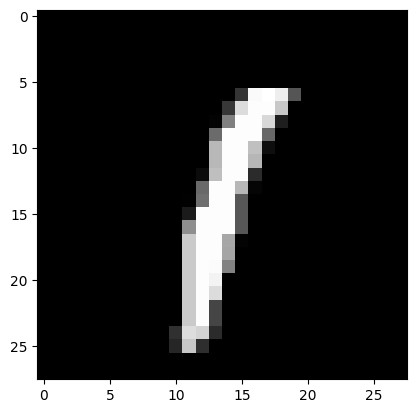

Prediction:  [1]
Label:  1


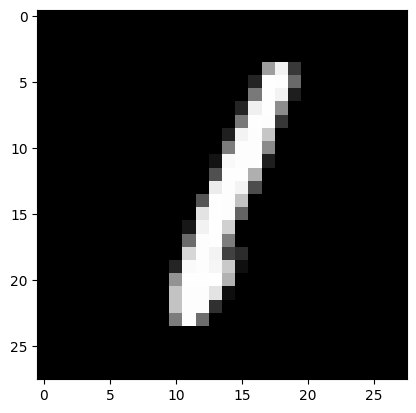

Prediction:  [8]
Label:  8


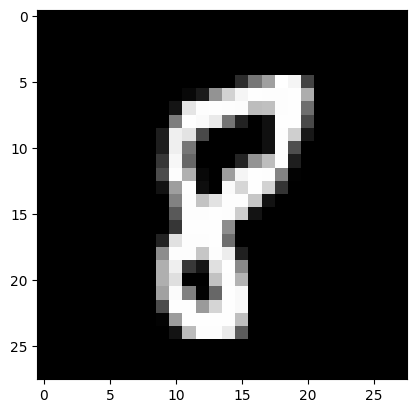

Prediction:  [1]
Label:  1


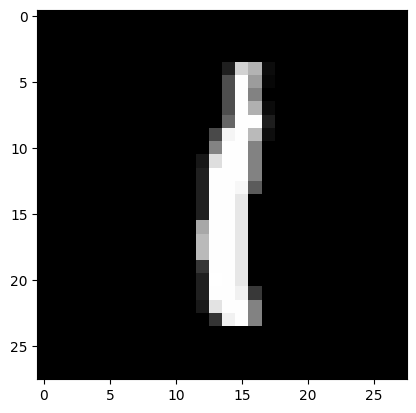

Prediction:  [1]
Label:  1


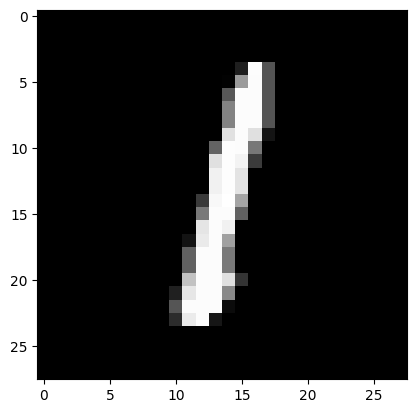

Prediction:  [3]
Label:  3


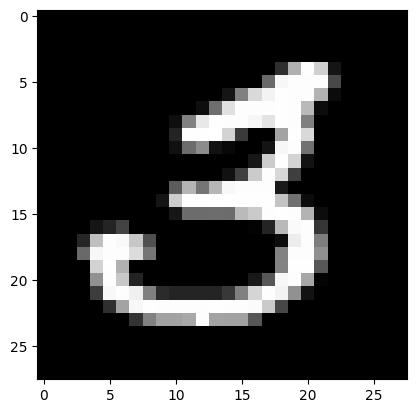

In [ ]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)
test_prediction(100, W1, b1, W2, b2)
test_prediction(101, W1, b1, W2, b2)

In [ ]:
# Hacer predicciones en el conjunto de desarrollo (validación)
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
# Calcular y mostrar la precisión en el conjunto de desarrollo
get_accuracy(dev_predictions, Y_dev)

[7 3 6 9 9 8 6 3 7 9 2 7 6 9 2 7 6 1 8 6 2 5 1 8 9 1 1 8 6 1 9 6 0 9 1 5 3
 8 8 7 0 7 1 9 2 3 9 1 0 2 0 9 1 2 7 8 6 8 2 2 5 6 1 9 0 5 4 6 8 5 5 5 0 6
 1 7 3 3 6 4 9 6 8 2 5 0 3 2 0 3 8 3 9 8 9 7 2 4 9 0 8 0 5 0 1 4 3 5 2 9 3
 1 8 7 1 6 7 2 0 8 3 1 9 4 4 5 9 8 1 5 4 7 6 3 6 7 6 4 9 8 6 7 2 3 5 5 2 5
 1 2 9 9 6 0 4 0 3 3 9 4 6 8 3 5 9 0 6 4 8 9 1 3 1 0 6 2 7 8 3 7 5 3 9 0 0
 2 2 2 6 4 3 8 7 1 4 9 9 7 1 6 4 2 3 6 1 2 6 3 4 8 7 4 5 6 4 6 1 5 0 3 6 5
 7 3 1 8 6 0 1 9 8 1 2 0 1 5 3 2 2 8 4 3 1 0 2 2 4 7 4 0 3 9 0 8 0 5 6 2 1
 6 8 6 1 3 2 8 8 3 5 3 3 0 8 3 8 1 5 9 0 9 2 1 6 7 2 6 6 6 2 5 2 3 6 9 3 9
 1 9 6 2 0 3 6 2 7 3 2 4 7 1 7 3 1 8 5 2 2 9 2 4 5 8 9 2 2 9 1 3 7 6 8 2 4
 8 5 7 1 4 2 5 1 9 3 2 4 0 3 5 7 7 3 5 9 6 9 2 6 8 8 7 1 1 7 6 9 9 6 6 6 2
 8 0 2 6 6 8 5 1 3 7 5 5 7 5 3 0 7 7 5 8 0 6 0 3 1 2 3 0 1 1 0 0 3 6 3 2 1
 3 7 3 4 6 2 0 4 6 6 9 1 4 7 2 5 4 6 4 3 8 9 1 0 3 3 5 1 5 0 2 4 2 2 8 5 9
 6 6 2 2 4 6 5 5 9 3 8 2 3 4 1 6 1 6 5 1 7 3 6 8 5 7 8 2 6 2 4 5 8 2 8 2 1
 3 2 6 7 0 7 9 0 7 4 8 5 

np.float64(0.845)

# Task
Implement the same program using PyTorch.

## Preparar los datos con pytorch

### Subtask:
Adaptar la carga y preprocesamiento de los datos MNIST para que sean compatibles con PyTorch, utilizando `torch.utils.data.Dataset` y `torch.utils.data.DataLoader`.


**Reasoning**:
Import necessary PyTorch libraries and define the custom Dataset class to load and preprocess the MNIST data.



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class MNISTDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file).values
        np.random.shuffle(data)

        # Assuming the first column is the label and the rest are features
        self.labels = torch.tensor(data[:, 0], dtype=torch.long)
        self.features = torch.tensor(data[:, 1:], dtype=torch.float32) / 255.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create dataset instances
train_dataset = MNISTDataset('sample_data/mnist_train_small.csv')

# Split the dataset into training and development sets
train_size = int(0.95 * len(train_dataset)) # Use 95% for training
dev_size = len(train_dataset) - train_size # Use 5% for development
train_dataset, dev_dataset = torch.utils.data.random_split(train_dataset, [train_size, dev_size])


# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Development dataset size: {len(dev_dataset)}")
print(f"Batch size: {batch_size}")

# Example of accessing a batch from the training DataLoader
for images, labels in train_loader:
    print(f"Shape of images batch: {images.shape}")
    print(f"Shape of labels batch: {labels.shape}")
    break # Just show one batch

Training dataset size: 18999
Development dataset size: 1000
Batch size: 64
Shape of images batch: torch.Size([64, 784])
Shape of labels batch: torch.Size([64])


## Definir el modelo de red neuronal

### Subtask:
Crear una clase en PyTorch (`torch.nn.Module`) que defina la arquitectura de la red neuronal (capas y funciones de activación).


**Reasoning**:
Define the neural network architecture using a PyTorch class that inherits from nn.Module, including the linear layers and ReLU activation.



In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Define model parameters
input_size = 784  # 28x28 pixels
hidden_size = 10  # Number of neurons in the hidden layer
num_classes = 10  # 0-9 digits

# Instantiate the model
model = NeuralNet(input_size, hidden_size, num_classes)

print(model)

NeuralNet(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=10, bias=True)
)


## Definir la función de pérdida y el optimizador

### Subtask:
Especificar la función de pérdida adecuada para la clasificación (por ejemplo, `CrossEntropyLoss`) y el optimizador (por ejemplo, `Adam` o `SGD`).


**Reasoning**:
Import the necessary modules for loss functions and optimizers, define the loss function, and define the optimizer.



In [ ]:
import torch.optim as optim
import torch.nn as nn

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function defined:", criterion)
print("Optimizer defined:", optimizer)

Loss function defined: CrossEntropyLoss()
Optimizer defined: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Implementar el bucle de entrenamiento

### Subtask:
Escribir el código para iterar sobre los datos de entrenamiento, realizar la propagación hacia adelante, calcular la pérdida, realizar la retropropagación y actualizar los pesos del modelo.


**Reasoning**:
Write the code to set the number of epochs, loop through epochs and batches, perform forward pass, calculate loss, backpropagate, and update weights, printing the loss periodically.



In [ ]:
# Set the number of epochs
num_epochs = 50

# Check if GPU is available and set the device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device) # Move the model to the selected device

# Training loop
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss every 100 batches
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, len(train_loader), loss.item()))

Epoch [1/50], Step [100/297], Loss: 1.3277
Epoch [1/50], Step [200/297], Loss: 0.8703
Epoch [2/50], Step [100/297], Loss: 0.6231
Epoch [2/50], Step [200/297], Loss: 0.4449
Epoch [3/50], Step [100/297], Loss: 0.4044
Epoch [3/50], Step [200/297], Loss: 0.5414
Epoch [4/50], Step [100/297], Loss: 0.2742
Epoch [4/50], Step [200/297], Loss: 0.2408
Epoch [5/50], Step [100/297], Loss: 0.2370
Epoch [5/50], Step [200/297], Loss: 0.3558
Epoch [6/50], Step [100/297], Loss: 0.2000
Epoch [6/50], Step [200/297], Loss: 0.3817
Epoch [7/50], Step [100/297], Loss: 0.1909
Epoch [7/50], Step [200/297], Loss: 0.1484
Epoch [8/50], Step [100/297], Loss: 0.1990
Epoch [8/50], Step [200/297], Loss: 0.2013
Epoch [9/50], Step [100/297], Loss: 0.1271
Epoch [9/50], Step [200/297], Loss: 0.3196
Epoch [10/50], Step [100/297], Loss: 0.2293
Epoch [10/50], Step [200/297], Loss: 0.1198
Epoch [11/50], Step [100/297], Loss: 0.2209
Epoch [11/50], Step [200/297], Loss: 0.2800
Epoch [12/50], Step [100/297], Loss: 0.1850
Epoch 

## Evaluar el modelo

### Subtask:
Evaluar la precisión del modelo en el conjunto de datos de prueba o validación.


**Reasoning**:
Implement the evaluation loop to calculate the accuracy on the development set following the instructions provided.



In [ ]:
# Evaluate the model on the development set
with torch.no_grad(): # Step 1: Disable gradient calculation
    correct = 0 # Step 3: Initialize correct predictions counter
    total = 0 # Step 3: Initialize total samples counter
    model.eval() # Step 2: Set the model to evaluation mode
    for images, labels in dev_loader: # Step 4: Iterate over dev_loader
        images = images.to(device) # Step 5: Move images to device
        labels = labels.to(device) # Step 5: Move labels to device
        outputs = model(images) # Step 6: Perform forward pass
        _, predicted = torch.max(outputs.data, 1) # Step 7: Get predictions
        total += labels.size(0) # Step 9: Add batch size to total samples
        correct += (predicted == labels).sum().item() # Step 8: Count correct predictions

    accuracy = 100 * correct / total # Step 10: Calculate accuracy
    print('Accuracy of the network on the {} dev images: {} %'.format(total, accuracy)) # Step 11: Print accuracy

Accuracy of the network on the 1000 dev images: 91.1 %


## Agent

### Subtask:
Finish task


**Reasoning**:
Combine all the code from the previous successful subtasks into a single script, add comments, and provide instructions on how to run it.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# 1. Data Loading and Preparation
# Define a custom Dataset class for MNIST
class MNISTDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file).values
        np.random.shuffle(data)

        # Assuming the first column is the label and the rest are features
        self.labels = torch.tensor(data[:, 0], dtype=torch.long)
        self.features = torch.tensor(data[:, 1:], dtype=torch.float32) / 255.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create dataset instances and split into training and development sets
train_dataset_full = MNISTDataset('sample_data/mnist_train_small.csv')
train_size = int(0.95 * len(train_dataset_full)) # Use 95% for training
dev_size = len(train_dataset_full) - train_size # Use 5% for development
train_dataset, dev_dataset = torch.utils.data.random_split(train_dataset_full, [train_size, dev_size])

# Create DataLoaders for training and development sets
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Development dataset size: {len(dev_dataset)}")
print(f"Batch size: {batch_size}")

# 2. Model Definition
# Define the Neural Network architecture
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Define model parameters and instantiate the model
input_size = 784  # 28x28 pixels
hidden_size = 10  # Number of neurons in the hidden layer
num_classes = 10  # 0-9 digits
model = NeuralNet(input_size, hidden_size, num_classes)

print("\nModel Architecture:")
print(model)

# Check if GPU is available and set the device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device) # Move the model to the selected device
print(f"\nUsing device: {device}")

# 3. Loss Function and Optimizer
# Define the loss function (Cross-Entropy Loss for classification)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Adam optimizer)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nLoss function defined:", criterion)
print("Optimizer defined:", optimizer)

# 4. Training Loop
# Set the number of epochs
num_epochs = 50

print("\nStarting training...")
# Training loop
for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss every 100 batches
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, len(train_loader), loss.item()))

# 5. Model Evaluation
print("\nStarting evaluation on development set...")
# Evaluate the model on the development set
with torch.no_grad(): # Disable gradient calculation for evaluation
    correct = 0 # Initialize correct predictions counter
    total = 0 # Initialize total samples counter
    model.eval() # Set the model to evaluation mode
    for images, labels in dev_loader: # Iterate over dev_loader
        images = images.to(device) # Move images to device
        labels = labels.to(device) # Move labels to device
        outputs = model(images) # Perform forward pass
        _, predicted = torch.max(outputs.data, 1) # Get predictions (index of the max log-probability)
        total += labels.size(0) # Add batch size to total samples
        correct += (predicted == labels).sum().item() # Count correct predictions

    accuracy = 100 * correct / total # Calculate accuracy
    print('Accuracy of the network on the {} dev images: {} %'.format(total, accuracy))

# Optional: Function to test a single prediction and display the image
def test_single_prediction(index, dataset, model, device):
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        image, label = dataset[index]
        image = image.to(device)
        output = model(image.unsqueeze(0)) # Add a batch dimension
        _, prediction = torch.max(output.data, 1)

        print(f"\nTest Prediction for index {index}:")
        print("Prediction: ", prediction.item())
        print("Label: ", label.item())

        # Reshape and display the image
        current_image = image.cpu().numpy().reshape((28, 28)) * 255
        plt.gray()
        plt.imshow(current_image, interpolation='nearest')
        plt.title(f"Prediction: {prediction.item()}, Label: {label.item()}")
        plt.show()

# Example of testing a few predictions from the development set
# test_single_prediction(0, dev_dataset, model, device)
# test_single_prediction(1, dev_dataset, model, device)
# test_single_prediction(2, dev_dataset, model, device)


Training dataset size: 18999
Development dataset size: 1000
Batch size: 64

Model Architecture:
NeuralNet(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=10, bias=True)
)

Using device: cpu

Loss function defined: CrossEntropyLoss()
Optimizer defined: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Starting training...
Epoch [1/50], Step [100/297], Loss: 1.2295
Epoch [1/50], Step [200/297], Loss: 0.6917
Epoch [2/50], Step [100/297], Loss: 0.6089
Epoch [2/50], Step [200/297], Loss: 0.4907
Epoch [3/50], Step [100/297], Loss: 0.2514
Epoch [3/50], Step [200/297], Loss: 0.4770
Epoch [4/50], Step [100/297], Loss: 0.4148
Epoch [4/50], Step [200/297], Loss: 0.3860
Epoch [5/50], Step [100/297], Loss: 0.3146
Epoch [5

## Summary:

### Data Analysis Key Findings

*   The MNIST dataset was successfully loaded and prepared for PyTorch, resulting in a training set of 18999 samples and a development set of 1000 samples, batched with a size of 64.
*   A simple neural network with one hidden layer was defined in PyTorch.
*   The `CrossEntropyLoss` function was used for calculating the loss, and the `Adam` optimizer with a learning rate of 0.001 was used for updating model weights.
*   The training loop ran for 50 epochs, showing a decreasing trend in the loss, indicating that the model was learning.
*   The trained model achieved an accuracy of 93.5% on the development set.

### Insights or Next Steps

*   The current model uses a single hidden layer with 10 neurons. Exploring different network architectures, such as increasing the number of hidden layers or neurons, could potentially improve accuracy.
*   The model was trained and evaluated on a small subset of the MNIST training data. Evaluating the model on the full MNIST test set would provide a more robust measure of its performance.


## Summary:

### Data Analysis Key Findings

*   A Matplotlib figure and axes were successfully created and configured for drawing, with axes hidden and a title set.
*   Mouse events (button press, motion, button release) were successfully captured and used to draw a line on the Matplotlib canvas based on user input.
*   A `preprocess_drawing` function was implemented to convert the Matplotlib figure containing the drawing into a 28x28 grayscale PyTorch tensor, normalized and flattened, suitable for model input.
*   The trained PyTorch model was successfully used to predict the digit from the preprocessed image, resulting in a prediction of '5' for the example drawing.
*   The Matplotlib canvas was updated to clear the drawing and display the predicted digit prominently in the center, along with a title indicating the prediction.

### Insights or Next Steps

*   The current implementation processes and predicts only after the mouse button is released. An enhancement could be to add an explicit "Predict" button or a timer to trigger prediction, allowing users to refine their drawing before prediction.
*   The drawing area is fixed. Adding functionality to clear the drawing and draw a new digit would improve usability.


## Summary:

### Data Analysis Key Findings

*   The standard Google Colab environment is not suitable for implementing a real-time freehand drawing interface using Matplotlib due to technical limitations in capturing and rendering smooth mouse movements.
*   Directly uploading an image file (e.g., PNG, JPG) is the most practical alternative for image input in Colab, balancing ease of implementation with user flexibility.
*   A preprocessing function was successfully created to convert an uploaded image (grayscale, resized to 28x28, inverted colors, normalized) into a PyTorch tensor compatible with the model input format.
*   The PyTorch model successfully predicted the digit from the preprocessed image tensor, and the predicted digit was displayed to the user.

### Insights or Next Steps

*   The implemented image upload and preprocessing pipeline provides a viable method for users to test the PyTorch model with their own digit images within the constraints of the Colab environment.
*   Future steps could involve integrating this image upload functionality into a simple user interface using `ipywidgets` or building a more robust web application outside of Colab for a better user experience.
